In [19]:
import csv
import copy
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd

from time import sleep
from collections import deque, defaultdict
from itertools import count
from typing import Any, Dict, Counter, List
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torch_optimizer as optim_extra

from importnb import Notebook
with Notebook():
    from LabLatencyModel import LatencyModel, MultiDULatencyModel
    from LabCacheEngine import CacheEngineEnv
    from LabUserRequest import UserRequestEvents
    from LabEnvWrapperKunkali import EnvWrapper

import os
import sys

sources_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if sources_path not in sys.path:
    sys.path.append(sources_path)

import Common.config as config
import Common.datatypes as datatypes
import Common.debugger as debugger
import Common.utils as utils

import importlib

importlib.reload(config)
importlib.reload(datatypes)
importlib.reload(debugger)
importlib.reload(utils)

<module 'Common.utils' from '/home/eduardo/Workspace/CacheVideoPredict360/Sources/Common/utils.py'>

In [20]:
UserTransition = datatypes.UserTransition
CachePolicy = datatypes.CachePolicy
CacheKey = datatypes.CacheKey

cfg = config.Config()
cfg.filename = f"ctrl_eps{cfg.epsilon_start}_lrdecay{cfg.learning_rate_decay}_gamma{cfg.gamma}.csv"
cfg.state_dim_ctrl = 2 * cfg.viewport + 2 * cfg.viewport 

debugger = debugger.debug

In [21]:
class DrlPolicy(CachePolicy):
    def __init__(self, cfg: Any = None):
        self.cfg = cfg
        self.cur_size = 0

        self.video_idx = [-1] * self.cfg.cache_size
        self.tile_idx = [[-1] * self.cfg.viewport for _ in range(self.cfg.cache_size)]

    def get(self, key: CacheKey) -> Any:
        return self.cache.get(key, None)

    def put(self, key: int, value: Any, size: int) -> list:
        """
        key   -> slot index
        value -> (video_id, tiles)
        size  -> fixed as 1 slot
        """
        evicted = []
        slot = key
        new_video, _ = value

        if new_video in self.video_idx:
            old_video_slot = self.video_idx.index(new_video)
            if old_video_slot != slot:
                # Swap video positions
                self.video_idx[slot], self.video_idx[old_video_slot] = (
                    self.video_idx[old_video_slot],
                    self.video_idx[slot],
                )

                # Swap tile mapping accordingly
                self.tile_idx[slot], self.tile_idx[old_video_slot] = (
                    self.tile_idx[old_video_slot],
                    self.tile_idx[slot],
                )

            self.cur_size = sum(1 for v in self.video_idx if v != -1)
            return evicted

        self.video_idx[slot] = new_video
        self.tile_idx[slot] = [-1] * self.cfg.viewport

        self.cur_size = sum(1 for v in self.video_idx if v != -1)
        return evicted

    def contains(self, key: CacheKey) -> bool:
        return key in self.video_idx

    def remove(self, key: CacheKey) -> bool:
        if key in self.video_idx:
            idx = self.video_idx.index(key)
            self.video_idx[idx] = -1
            self.tile_idx[idx] = [-1] * self.cfg.viewport
            self.cur_size = sum(1 for v in self.video_idx if v != -1)
            return True
        return False

    def clear(self) -> None:
        self.video_idx = [-1] * self.cfg.cache_size
        self.tile_idx = [[-1] * self.cfg.viewport for _ in range(self.cfg.cache_size)]
        self.cur_size = 0

    def keys(self):
        return self.video_idx
    
    def get_capacity(self) -> int:
        return self.cur_size
    
    def update_size(self):
        self.cur_size = sum(1 for v in self.video_idx if v != -1)

    def stats(self) -> Dict[str, Any]:
        return {
            'current_size': self.cur_size,
            'capacity': self.cfg.cache_size,
            'num_items': len([v for v in self.video_idx if v != -1])
        }

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ReplayBuffer:
    def __init__(self, capacity: int = 2000):
        self.memory = deque(maxlen=capacity)
    
    def push(self, s, a, r, ns, d):
        self.memory.append((s, a, r, ns, d))
    
    def sample(self, batch_size: int):
        return random.sample(self.memory, batch_size)
    
    def __len__(self):
        return len(self.memory)

class NStepReplayBuffer:
    def __init__(self, capacity, n_step, gamma):
        self.memory = deque(maxlen=capacity)
        self.n_step_buffer = deque(maxlen=n_step)
        self.n_step = n_step
        self.gamma = gamma

    def push(self, s, a, r, ns, done):
        self.n_step_buffer.append((s, a, r, ns, done))
        if len(self.n_step_buffer) < self.n_step:
            return
        
        # Compute N-step discounted reward
        # G = r1 + gamma*r2 + ... + gamma^(n-1)*rn
        reward, next_state, done_ = self._get_n_step_info()
        state, action, _, _, _ = self.n_step_buffer[0]
        self.memory.append((state, action, reward, next_state, done_))

    def _get_n_step_info(self):
        reward = 0
        for i, transition in enumerate(self.n_step_buffer):
            reward += (self.gamma ** i) * transition[2]

        # reward = reward / self.n_step # Normalize reward by n_step to prevent large values

        return reward, self.n_step_buffer[-1][3], self.n_step_buffer[-1][4]
    
    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    
    def __len__(self):
        return len(self.memory)

class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        hidden = hidden_dim
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.out = nn.Linear(hidden, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

class MetaController:
    def __init__(self, cfg):
        self.cfg = cfg
        self.step = 0
        self.n_step = cfg.n_step
        self.state_dim = cfg.state_dim_meta
        self.num_actions = cfg.num_goals   # capacity + 1

        self.gamma = cfg.gamma
        self.epsilon = cfg.epsilon_start
        self.epsilon_min = cfg.epsilon_min
        self.epsilon_decay = cfg.epsilon_decay
        self.batch_size = cfg.batch_size
        self.tau = cfg.tau

        self.buffer = NStepReplayBuffer(cfg.buffer_capacity, self.n_step, self.gamma)

        self.policy_net = QNetwork(self.state_dim, self.num_actions).to(device)
        self.target_net = QNetwork(self.state_dim, self.num_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=cfg.learning_rate)

        self.scheduler = optim.lr_scheduler.ExponentialLR(
            self.optimizer, gamma=cfg.learning_rate_decay
        )

        self.loss_fn = nn.MSELoss()
        self.nb_interval = cfg.nb_interval

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.num_actions - 1)

        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32).to(device).unsqueeze(0)
            qvals = self.policy_net(state_t)
            return qvals.argmax().item()

    def remember(self, s, a, r, ns, done):
        self.buffer.push(s, a, r, ns, done)

    def train_step(self):
        self.step += 1
        if self.step % self.nb_interval == 0 and \
           len(self.buffer) >= self.batch_size:
            self.learn()

    def learn(self):
        batch = self.buffer.sample(self.batch_size)
        s, a, r, ns, d = zip(*batch)

        s = torch.tensor(np.stack(s), dtype=torch.float32).to(device)
        ns = torch.tensor(np.stack(ns), dtype=torch.float32).to(device)
        a = torch.tensor(a, dtype=torch.int64).to(device)
        r = torch.tensor(r, dtype=torch.float32).to(device)
        d = torch.tensor(d, dtype=torch.float32).to(device)

        with torch.no_grad():
            next_q = self.target_net(ns).max(1)[0]
            n_step_gamma = self.gamma ** self.n_step
            q_target = r + n_step_gamma * next_q * (1.0 - d)

        q_expected = self.policy_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

        loss = self.loss_fn(q_expected, q_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        # self.scheduler.step()
        self.update_target()

        debugger.log('train_loss', loss.item())
        debugger.log('epsilon', self.epsilon)

    def update_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def soft_update(self):
        for tparam, pparam in zip(self.target_net.parameters(), self.policy_net.parameters()):
            tparam.data.copy_(tparam.data * (1.0 - self.tau) + pparam.data * self.tau)

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

class MultiHeadQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_heads=4, hidden_dim=128):
        super().__init__()

        # shared encoder
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # independent heads
        self.heads = nn.ModuleList([
            nn.Linear(hidden_dim, action_dim)
            for _ in range(num_heads)
        ])

    def forward(self, x):
        z = self.shared(x)
        return torch.stack([h(z) for h in self.heads], dim=1)

class Controller:
    def __init__(self, cfg):
        self.cfg = cfg
        self.step = 0
        self.state_dim = cfg.state_dim_ctrl
        self.low_dim = cfg.num_low_actions
        self.n_step = cfg.n_step

        self.gamma = cfg.gamma
        self.epsilon = cfg.epsilon_start
        self.epsilon_min = cfg.epsilon_min
        self.epsilon_decay = cfg.epsilon_decay
        self.batch_size = cfg.batch_size
        self.tau = cfg.tau

        # self.buffer = ReplayBuffer(cfg.buffer_capacity)
        self.buffer = NStepReplayBuffer(cfg.buffer_capacity, self.n_step, self.gamma)

        self.policy_net = MultiHeadQNetwork(
            self.state_dim,
            self.low_dim,
            num_heads=4
        ).to(device)
        self.target_net = MultiHeadQNetwork(
            self.state_dim,
            self.low_dim,
            num_heads=4
        ).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=cfg.learning_rate)

        self.scheduler = optim.lr_scheduler.ExponentialLR(
            self.optimizer, gamma=cfg.learning_rate_decay
        )

        self.loss_fn = nn.MSELoss()
        self.nb_interval = cfg.nb_interval

    def select_action(self, state):
        if random.random() < self.epsilon:
            return [random.randint(0, self.low_dim - 1) for _ in range(4)]

        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            qvals = self.policy_net(state)   # (1, 4, actions)
            actions = qvals.argmax(dim=2).squeeze(0)
            return actions.tolist()
        
    def remember(self, s, action, r, ns, done):
        self.buffer.push(s, action, r, ns, done)

    def train_step(self):
        self.step += 1
        if self.step % self.nb_interval == 0 and \
           len(self.buffer) >= self.batch_size:
            self.learn()

    def learn(self):
        batch = self.buffer.sample(self.batch_size)
        s, a, r, ns, d = zip(*batch)

        s = torch.tensor(np.stack(s), dtype=torch.float32).to(device)
        ns = torch.tensor(np.stack(ns), dtype=torch.float32).to(device)
        a = torch.tensor(np.stack(a), dtype=torch.long).to(device)
        r = torch.tensor(r, dtype=torch.float32).to(device).unsqueeze(1)
        d = torch.tensor(d, dtype=torch.float32).to(device).unsqueeze(1)

        # ---------- target ----------
        with torch.no_grad():
            next_q = self.target_net(ns)
            q_max_next = next_q.max(dim=2)[0]
            q_target = r + self.gamma * q_max_next * (1 - d)

        # ---------- expected ----------
        q_expected = self.policy_net(s).gather(2, a.unsqueeze(2)).squeeze(2)

        loss = self.loss_fn(q_expected, q_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.scheduler.step()
        self.update_target()

        debugger.log('train_loss_ctrl', loss.item())
        debugger.log('epsilon_ctrl', self.epsilon)

    def update_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def soft_update(self):
        for tparam, pparam in zip(self.target_net.parameters(), self.policy_net.parameters()):
            tparam.data.copy_(
                tparam.data * (1.0 - self.tau) + pparam.data * self.tau
            )

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def reset_step(self):
        self.step = 0

In [23]:
class FeatureAdapter:
    def __init__(self, env: CacheEngineEnv, cfg: Any):
        self.env = env
        self.cfg = cfg

        self.video_hist_short = deque(maxlen=cfg.h_short)
        self.video_hist_long = deque(maxlen=cfg.h_long)
        self.tile_hist_short = deque(maxlen=cfg.h_short * cfg.viewport)
        self.tile_hist_long = deque(maxlen=cfg.h_long * cfg.viewport)
        self.tiles_hist_short = deque(maxlen=cfg.h_short)
        self.tiles_hist_long = deque(maxlen=cfg.h_long)

        self.video_freq_short = defaultdict(int)
        self.video_freq_long = defaultdict(int)
        self.tile_freq_short = defaultdict(int)
        self.tile_freq_long = defaultdict(int)
        self.tiles_freq_short = defaultdict(int)
        self.tiles_freq_long = defaultdict(int)

        self.ch_video_hist = deque(maxlen=cfg.h_long)
        self.ch_viewport_hist = deque(maxlen=cfg.h_long)

        self.all_video_hist = []

    def reset_history(self):
        queues = (
            self.video_hist_short,
            self.video_hist_long,
            self.tiles_hist_short,
            self.tiles_hist_long,
            self.tile_hist_short,
            self.tile_hist_long,
            self.ch_video_hist,
            self.ch_viewport_hist,            
        )
        freqs = (
            self.video_freq_short,
            self.video_freq_long,
            self.tiles_freq_short,
            self.tiles_freq_long,
            self.tile_freq_short,
            self.tile_freq_long,
        )
        
        for q in queues:
            q.clear()
        for f in freqs:
            f.clear()

        self.all_video_hist = []
        
    def update_history(self, vid: int, tiles: list[int]):       
        self._update_window(self.video_hist_short, self.video_freq_short, vid)
        self._update_window(self.video_hist_long, self.video_freq_long, vid)

        tiles = tuple(tiles) if tiles is not None else None

        if tiles is None:
            return

        self._update_window(self.tiles_hist_short, self.tiles_freq_short, tiles)
        self._update_window(self.tiles_hist_long, self.tiles_freq_long, tiles)

        for tile in tiles:
            self._update_window(self.tile_hist_short, self.tile_freq_short, (vid, tile))
            self._update_window(self.tile_hist_long, self.tile_freq_long, (vid, tile))

    def update_history_single(self, item):
        if isinstance(item, int):
            self._update_window(self.video_hist_short, self.video_freq_short, item)
            self._update_window(self.video_hist_long, self.video_freq_long, item)
        elif isinstance(item, tuple) and len(item) == 2:
            self._update_window(self.tile_hist_short, self.tile_freq_short, item)
            self._update_window(self.tile_hist_long, self.tile_freq_long, item)
        elif isinstance(item, tuple) and all(isinstance(i, int) for i in item):
            self._update_window(self.tiles_hist_short, self.tiles_freq_short, item)
            self._update_window(self.tiles_hist_long, self.tiles_freq_long, item)

    def update_ch_history(self, vid: int, viewport: list[int]) -> None:
        self.all_video_hist.append(vid)

        video_cache_index = self.env.mec_cache.policy.video_idx
        tile_cache_index = self.env.mec_cache.policy.tile_idx

        hit = 1 if vid in video_cache_index else 0
        self.ch_video_hist.append(hit)

        if not hit:
            viewport_vector = [0,0,0,0]
        else:
            idx = video_cache_index.index(vid)
            cached_tiles = tile_cache_index[idx]
            viewport_vector = [1 if tile in cached_tiles else 0 for tile in viewport]

        self.ch_viewport_hist.append(viewport_vector)

    def compute_reward_layer_0(self, window_size: int = None) -> float:
        if window_size is None:
            window_size = len(self.ch_video_hist)

        ch_video_list = list(self.ch_video_hist)[-window_size:]
        psnr_layer_0 = 30 * sum(ch_video_list)
        
        return psnr_layer_0 / len(ch_video_list) if ch_video_list else 0

    def compute_reward_layer_1(self, window_size: int = None) -> float:
        if window_size is None:
            window_size = len(self.ch_viewport_hist)

        ch_viewport_list = list(self.ch_viewport_hist)[-window_size:]
        psnr_layer_1 = 2.5 * sum(sum(viewport) for viewport in ch_viewport_list)

        return psnr_layer_1 / len(ch_viewport_list) if ch_viewport_list else 0

    def compute_reward(self, window_size: int = None) -> float:
        if window_size is None:
            window_size = len(self.ch_video_hist)
        
        ch_video_list = list(self.ch_video_hist)[-window_size:]
        ch_viewport_list = list(self.ch_viewport_hist)[-window_size:]

        psnr_layer_0 = 30 * sum(ch_video_list)
        psnr_layer_1 = 2.5 * sum(sum(viewport) for viewport in ch_viewport_list)

        total_items = len(ch_video_list)
        return (psnr_layer_0 + psnr_layer_1) / total_items if total_items > 0 else 0

    def compute_meta_potential(self) -> float:
        video_cache_index = self.env.mec_cache.policy.video_idx
        potential = 0.0
        
        if self.video_hist_long.maxlen > 0:
            for vid in video_cache_index:
                if vid != -1:
                    prob = self.video_freq_long.get(vid, 0) / self.video_hist_long.maxlen
                    potential += prob
                    
        return potential

    def compute_ctrl_potential(self) -> float:
        video_cache_index = self.env.mec_cache.policy.video_idx
        tile_cache_index = self.env.mec_cache.policy.tile_idx
        potential = 0.0
        
        if self.tile_hist_long.maxlen > 0:
            for vid_idx, vid in enumerate(video_cache_index):
                if vid == -1: continue
                
                for tile in tile_cache_index[vid_idx]:
                    if tile != -1:
                        prob = self.tile_freq_long.get((vid, tile), 0) / self.tile_hist_long.maxlen
                        potential += prob
                        
        return potential

    def _update_window(self, hist_queue: deque, freq_dict: Dict, item):
        if len(hist_queue) == hist_queue.maxlen:
            old_item = hist_queue.popleft()
            freq_dict[old_item] -= 1
            if freq_dict[old_item] == 0:
                del freq_dict[old_item]
        hist_queue.append(item)
        freq_dict[item] += 1

In [24]:
class NetworkAdapter:
    def __init__(self, env: EnvWrapper, feature_adapter: FeatureAdapter, cfg: Any):
        self.env = env
        self.cfg = cfg
        self.features = feature_adapter

        self.C = self.cfg.cache_size  # paper's cache capacity (videos)
        self.k = self.cfg.viewport    # paper's tiles per video (enhancement)

        print(f"NetworkAdapter initialized with capacity: {self.C} videos, {self.k} tiles per video")

    def build_observation(self, vid: int, viewport: list = None) -> np.ndarray:
        video_cache_index = self.env.mec_cache.policy.video_idx
        tile_cache_index = self.env.mec_cache.policy.tile_idx

        if viewport is None:
            
            x_s = np.zeros(self.C, dtype=np.float32)
            x_l = np.zeros(self.C, dtype=np.float32)

            for vid_i, v in enumerate(video_cache_index):
                if v == -1:
                    continue
                x_s[vid_i] = self.features.video_freq_short.get(v, 0) / self.features.video_hist_short.maxlen
                x_l[vid_i] = self.features.video_freq_long.get(v, 0) / self.features.video_hist_long.maxlen

            z_s = np.array(
                [self.features.video_freq_short.get(vid, 0) / self.features.video_hist_short.maxlen], dtype=np.float32
            )
            z_l = np.array(
                [self.features.video_freq_long.get(vid, 0) / self.features.video_hist_long.maxlen], dtype=np.float32
            )

            features = np.concatenate([x_s, x_l, z_s, z_l], axis=0)
            return features
        else:
            
            vid_idx = self.env.mec_cache.get_video_cache_idx(vid)
            vp_tiles = tile_cache_index[vid_idx]
            
            y_s = np.zeros(self.k, dtype=np.float32)
            y_l = np.zeros(self.k, dtype=np.float32)

            for til_i, t in enumerate(vp_tiles):
                if t == -1:
                    continue
                y_s[til_i] = self.features.tile_freq_short.get((vid, t), 0) / self.features.tile_hist_short.maxlen
                y_l[til_i] = self.features.tile_freq_long.get((vid, t), 0) / self.features.tile_hist_long.maxlen

            z_s = np.zeros(len(viewport), dtype=np.float32)
            z_l = np.zeros(len(viewport), dtype=np.float32)

            for i, tile in enumerate(viewport):
                z_s[i] = self.features.tile_freq_short.get((vid, tile), 0) / self.features.tile_hist_short.maxlen
                z_l[i] = self.features.tile_freq_long.get((vid, tile), 0) / self.features.tile_hist_long.maxlen

            features = np.concatenate([y_s, y_l, z_s, z_l], axis=0)
            return features

    def reset(self):
        obs, info = self.env.reset()
        self.features.reset_history()

        return obs, info
    
    def env_is_done(self) -> bool:
        return self.env.users_env.all_users_done()

In [25]:
def save_training_results(
    path_,
    filename,
    ep, 
    total_reward, 
    cache_hits, 
    cache_misses, 
    agent
):
    with open(os.path.join(path_, filename), 'a', newline='') as f:
        fieldnames = [
            'episode', 
            'total_reward', 
            'cache_hits', 
            'cache_misses', 
            'epsilon',
            'lr'
        ]
        writer_results = csv.DictWriter(f, fieldnames=fieldnames)

        if ep == 0:
            writer_results.writeheader()
        
        writer_results.writerow({
            'episode': ep,
            'total_reward': round(float(total_reward), 2),
            'cache_hits': cache_hits,
            'cache_misses': cache_misses,
            'lr': f"{agent.scheduler.get_last_lr()[0]:.10f}" if agent else None,
            'epsilon': round(float(agent.epsilon), 4) if agent else None
        })

def update_metrics(info: dict, reward: float) -> tuple[float, int, int, int, int]:
    enh_hits = info.get("enh_layer_hits", 0)
    base_hits = info.get("base_layer_hits", 0)
    enh_misses = info.get("enh_layer_misses", 0)
    base_misses = info.get("base_layer_misses", 0)

    return reward, (enh_hits + base_hits), (enh_misses + base_misses), base_hits, base_misses

def build_latency_model(cfg):
    """Build and return the MultiDULatencyModel."""
    P = cfg.n_nodes
    max_U = cfg.n_users

    return MultiDULatencyModel(
        P=P,
        max_U=max_U,
        R_M_D=80e6,
        R_C_M=125e6,
        mu=2e7,
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 20e6, dtype=float),
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float),
        rhoT_p=[0.2],
        lambda_p=[0.05],
        du_fixed_delay=0.001,
        mec_fixed_delay=0.005,
        cloud_fixed_delay=0.1
    )

def build_environment(cfg):
    """Construct the full multi-component environment wrapper."""
    du_caches = []

    # DRL Caching Policy
    policy = DrlPolicy(cfg=cfg)

    # MEC Cache Engine
    mec_cache = CacheEngineEnv(
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n_gops=cfg.n_gops,
        cache_capacity=cfg.cache_capacity,
        policy=policy
    )

    # User request generator
    users_env = UserRequestEvents(
        n_nodes=cfg.n_nodes,
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_gops=cfg.n_gops,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n=cfg.n,
        m=cfg.m,
        arrival_rate=cfg.arrival_rate,
        zipf_alpha=cfg.zipf_alpha
    )

    # Latency Model
    latency_model = build_latency_model(cfg)

    # Wrapping all into the main training environment
    return EnvWrapper(
        cfg=cfg,
        n=cfg.n,
        m=cfg.m,
        n_layers=cfg.n_layers,
        users_env=users_env,
        du_caches=du_caches,
        mec_cache=mec_cache,
        latency_model=latency_model,
        theta=cfg.theta,
        lam=cfg.lam,
        max_steps=cfg.max_steps,
        prefetch_fn=lambda cache, action: cache.drl_prefetching_kulkarni(action),
        reward_fn=lambda env, reqs: env.compute_reward(reqs),
        debugger=debugger
    )

In [26]:
def run_episode(episode, env, meta, ctrl, net_adapter, cfg):
    """Run one full training episode."""
    _, info = net_adapter.reset()

    total_reward = 0.0
    cache_hits = cache_misses = 0
    base_hits = base_misses = 0

    env.warmup_phase(net_adapter)

    for step in count():

        req_state = info.get("user_request", None)
        
        _, reward, _, info = env.step(meta, ctrl, net_adapter, req_state)

        delta_r, hits, misses, bs_hits, bs_miss = update_metrics(info, reward)
        total_reward += delta_r
        cache_hits += hits
        cache_misses += misses
        base_hits += bs_hits
        base_misses += bs_miss

        if net_adapter.env_is_done():
            break

        debugger.log('cache_hits', hits)
        debugger.log('cache_misses', misses)
        debugger.log('step_reward', reward)
        debugger.log('cumulative_reward', total_reward)

        # print(f"Episode {episode} | Step {step} | Reward: {reward:.2f} | Total Reward: {total_reward:.2f} | Hits: {cache_hits} | Misses: {cache_misses}")

    return total_reward, cache_hits, cache_misses, base_hits, base_misses

def train(cfg):
    print("\n--- Starting DRL Caching System ---")

    env = build_environment(cfg)

    meta = MetaController(cfg)
    ctrl = Controller(cfg)

    feature_adapter = FeatureAdapter(env, cfg)
    net_adapter = NetworkAdapter(env, feature_adapter, cfg)

    date_dir = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")

    for episode in range(cfg.n_episodes):

        total_reward, hits, misses, bs_hits, bs_miss = run_episode(
            episode, env, meta, ctrl, net_adapter, cfg
        )

        ctrl.update_epsilon()
        meta.update_epsilon()

        save_training_results(
            path_=cfg.path_results,
            filename=cfg.filename,
            ep=episode,
            total_reward=total_reward,
            cache_hits=hits,
            cache_misses=misses,
            agent=meta
        )

        debugger.log('lr', ctrl.scheduler.get_last_lr()[0])
        debugger.log('epsilon', meta.epsilon)

        hit_rate = hits / (hits + misses + 1e-9)
        print(f"--- Episode {episode} | R: {total_reward:.2f} | HR: {hit_rate:.2f} | BHR: {bs_hits / (bs_hits + bs_miss + 1e-9):.2f} ---")

        debug_path = os.path.join(cfg.path_results, date_dir)
        os.makedirs(debug_path, exist_ok=True)

        # plot_cache_alignment(
        #     env, 
        #     net_adapter.features.all_video_hist, 
        #     top_k=env.mec_cache.policy.cfg.cache_size
        # )

        # debugger.histogram("base_action", "Base Controller Decisions")
        # debugger.histogram("enh_layer_1", "Enh Layer 1 Controller Decisions")
        # debugger.histogram("enh_layer_2", "Enh Layer 2 Controller Decisions")
        # debugger.histogram("enh_layer_3", "Enh Layer 3 Controller Decisions")
        # debugger.histogram("enh_layer_4", "Enh Layer 4 Controller Decisions")

        debugger.save_results(filepath=f"{debug_path}/debug_ep{episode}")
        debugger.clear()
        print("-" * 50)

if __name__ == "__main__":
    train(cfg)


--- Starting DRL Caching System ---
NetworkAdapter initialized with capacity: 50 videos, 4 tiles per video
--- Episode 0 | R: 168705.57 | HR: 0.36 | BHR: 0.43 ---
Results saved to /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-02-25_15-03/debug_ep0
--------------------------------------------------
--- Episode 1 | R: 164789.41 | HR: 0.35 | BHR: 0.42 ---
Results saved to /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-02-25_15-03/debug_ep1
--------------------------------------------------
--- Episode 2 | R: 171376.36 | HR: 0.37 | BHR: 0.43 ---
Results saved to /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-02-25_15-03/debug_ep2
--------------------------------------------------
--- Episode 3 | R: 181944.69 | HR: 0.39 | BHR: 0.46 ---
Results saved to /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-02-25_15-03/debug_ep3
--------------------------------------------------
--- Episode 4 | R: 183244.90 | HR: 0.39 | BHR: 0.46 ---
Results saved to /ho

Loading data from: /home/eduardo/Workspace/CacheVideoPredict360/Results/ctrl_eps0.05_lrdecay0.9995_gamma0.99.csv


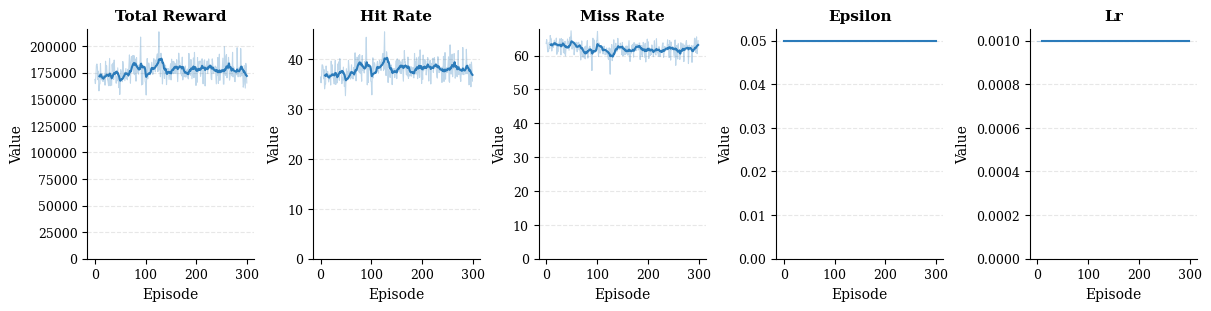

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------
# 1. Publication Style Configuration
# ----------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True
})

# Professional color for line plots
PRIMARY_COLOR = "#2b7bba"

# ----------------------------------------------------------------
# 2. Data Loading & Smoothing
# ----------------------------------------------------------------
cfg.filename = f"ctrl_eps{cfg.epsilon_start}_lrdecay{cfg.learning_rate_decay}_gamma{cfg.gamma}.csv"
path = cfg.path_results + "/" + cfg.filename

print(f"Loading data from: {path}")

df = pd.read_csv(path)

total = (df["cache_hits"] + df["cache_misses"]).replace(0, np.nan)
df["hit_rate"] = (df["cache_hits"] / total) * 100
df["miss_rate"] = (df["cache_misses"] / total) * 100

# Metrics to plot
metrics = ["total_reward", "hit_rate", "miss_rate", "epsilon", "lr"]
window_size = 10  # Adjust smoothing window as needed

# ----------------------------------------------------------------
# 3. Plotting logic
# ----------------------------------------------------------------
# Adjusted figsize for a 4-column row (standard for full-width paper figures)
fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), sharex=True)

for ax, col in zip(axes, metrics):
    # Plot raw data with transparency (alpha)
    ax.plot(df["episode"], df[col], color=PRIMARY_COLOR, alpha=0.3, linewidth=0.8, label='Raw')
    
    # Plot moving average for clearer trend (except for epsilon which is usually linear)
    if col != "epsilon":
        smoothed = df[col].rolling(window=window_size).mean()
        ax.plot(df["episode"], smoothed, color=PRIMARY_COLOR, linewidth=1.5, label='Trend')
    else:
        # Just a solid line for Epsilon
        ax.plot(df["episode"], df[col], color=PRIMARY_COLOR, linewidth=1.5)

    # Stylistic cleanup
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Episode")
    
    # Remove redundant Y-labels to save space, or keep for clarity
    ax.set_ylabel("Value") 
    
    series = df[col].dropna()
    if not series.empty:
        ymin = series.min()
        ymax = series.max()
        pad = (ymax - ymin) * 0.05 if ymax != ymin else 1.0
        ax.set_ylim(bottom=0)

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Tufte-style: remove top/right spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Optional: Add a single legend to the first plot if needed
# axes[0].legend(frameon=False)

plt.show()
fig.savefig("drl_caching_metrics.png", dpi=300)